<a href="https://colab.research.google.com/github/EiderHernandezProgramacion/Lenguajes-de-programacion/blob/main/CriptoUnoA_notebook_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ₿ CRIPTO UNO A — Fondo de Inversión
## Bitcoin (BTC) + Solana (SOL)

---

### 📋 INSTRUCCIONES — Ejecuta las celdas EN ORDEN

**Pasos:**
1. ▶️ **Celda 1** — Instalar librerías (espera que termine)
2. ▶️ **Celda 2** — Importar librerías
3. ▶️ **Celda 3** — Descargar datos de BTC y SOL
4. ▶️ **Celda 4** — Gráfica de precios
5. ▶️ **Celda 5** — Rendimiento acumulado comparado
6. ▶️ **Celda 6** — Volatilidad anualizada
7. ▶️ **Celda 7** — Drawdown (peor caída histórica)
8. ▶️ **Celda 8** — Días negativos
9. ▶️ **Celda 9** — Estrategia Stop Loss
10. ▶️ **Celda 10** — Gráfica con líneas de referencia
11. ▶️ **Celda 11** — Backtesting vs Buy & Hold
12. ▶️ **Celda 12** — Caídas extremas y recuperación
13. ▶️ **Celda 13** — Crear app.py
14. ▶️ **Celda 14** — Instalar Streamlit y pyngrok
15. ▶️ **Celda 15** — Verificar app.py
16. ▶️ **Celda 16** — Lanzar la app con ngrok

> 💡 **Tip:** Para ejecutar una celda presiona **Shift + Enter** o haz clic en el botón ▶️ a la izquierda de cada celda.

In [1]:
# ============================================================
# CELDA 1 — INSTALAR LIBRERÍAS
# ⏳ Espera a que el ícono de carga desaparezca antes de continuar
# ============================================================
!pip install yfinance pandas plotly

In [2]:
# ============================================================
# CELDA 2 — IMPORTAR LIBRERÍAS
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [3]:
# ============================================================
# CELDA 3 — DESCARGAR DATOS DE BTC Y SOL
# ============================================================
import yfinance as yf
from datetime import date

hoy = date.today().strftime('%Y-%m-%d')

btc = yf.download('BTC-USD', start='2024-01-01', end=hoy, interval='1d')
print('✅ BTC descargado:', len(btc), 'días')
btc.head()

sol = yf.download('SOL-USD', start='2024-01-01', end=hoy, interval='1d')
print('✅ SOL descargado:', len(sol), 'días')
sol.head()

/tmp/ipykernel_11031/2978139046.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2024-01-01', end=hoy, interval='1d')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11031/2978139046.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sol = yf.download('SOL-USD', start='2024-01-01', end=hoy, interval='1d')


✅ BTC descargado: 885 días


[*********************100%***********************]  1 of 1 completed

✅ SOL descargado: 885 días


Price,Close,High,Low,Open,Volume
Ticker,SOL-USD,SOL-USD,SOL-USD,SOL-USD,SOL-USD
Date,,,,,
2024-01-01,109.508682,109.508682,101.512810,101.512810,2157671990
2024-01-02,106.611221,116.882492,106.388985,109.549065,3782057553
2024-01-03,98.594437,109.848091,92.923668,106.616531,5472216595
2024-01-04,105.077538,107.982468,97.108330,98.586975,3272723247
2024-01-05,99.978790,105.235428,95.942726,105.052010,3022127826


In [4]:
# ============================================================
# CELDA 4 — GRÁFICA DE PRECIOS HISTÓRICOS
# ============================================================
fig = px.line(x=btc.index, y=btc['Close']['BTC-USD'], title='BTC-USD 2024-2026',
              color_discrete_sequence=['#00d4ff'])
fig.update_layout(template='plotly_dark')
fig.show()

fig = px.line(x=sol.index, y=sol['Close']['SOL-USD'], title='SOL-USD 2024-2026',
              color_discrete_sequence=['#7c3aed'])
fig.update_layout(template='plotly_dark')
fig.show()

In [5]:
# ============================================================
# CELDA 5 — RENDIMIENTO ACUMULADO COMPARADO
# ============================================================
import yfinance as yf
import plotly.express as px
import pandas as pd

tickers = ['BTC-USD', 'SOL-USD']
data = yf.download(tickers, start='2024-01-01')['Close']

# Rendimiento total del período
rend = (data.iloc[-1] / data.iloc[0] - 1) * 100
print('Rendimiento total del período:')
print(rend.sort_values(ascending=False))

# Rendimiento acumulado base 100
daily_returns = data.pct_change().dropna()
rendimiento_acumulado_df = (1 + daily_returns).cumprod() * 100
rendimiento_acumulado_df = rendimiento_acumulado_df.reset_index()
rendimiento_acumulado = rendimiento_acumulado_df.melt(
    id_vars=['Date'], var_name='Cripto', value_name='Valor de $100 invertidos')

fig = px.line(rendimiento_acumulado,
              x='Date',
              y='Valor de $100 invertidos',
              color='Cripto',
              color_discrete_map={'BTC-USD': '#00d4ff', 'SOL-USD': '#7c3aed'},
              title='Rendimiento Acumulado — BTC vs SOL (Base 100)')
fig.update_layout(template='plotly_dark')
fig.show()

/tmp/ipykernel_11031/397070066.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  2 of 2 completed


Rendimiento total del período:
Ticker
BTC-USD    43.710084
SOL-USD   -36.799533
dtype: float64


In [6]:
# ============================================================
# CELDA 6 — VOLATILIDAD ANUALIZADA
# ============================================================
import numpy as np
import pandas as pd

btc['retorno'] = btc['Close']['BTC-USD'].pct_change()
sol['retorno'] = sol['Close']['SOL-USD'].pct_change()

vol_anual_btc = btc['retorno'].std() * np.sqrt(252)
print(f'Volatilidad anual BTC: {vol_anual_btc*100:.2f}%')

vol_anual_sol = sol['retorno'].std() * np.sqrt(252)
print(f'Volatilidad anual SOL: {vol_anual_sol*100:.2f}%')

volatilidad = pd.Series({'BTC': vol_anual_btc * 100, 'SOL': vol_anual_sol * 100})

fig = px.bar(x=volatilidad.index, y=volatilidad.values,
             title='📊 Volatilidad Anualizada — BTC vs SOL',
             labels={'x': 'Cripto', 'y': 'Volatilidad (%)'},
             color=volatilidad.index,
             color_discrete_map={'BTC': '#00d4ff', 'SOL': '#7c3aed'})
fig.update_layout(template='plotly_dark')
fig.show()

# Retornos diarios BTC
fig_btc_ret = px.line(x=btc.index, y=btc['retorno'],
                      title='Retornos Diarios de BTC-USD',
                      color_discrete_sequence=['#00d4ff'])
fig_btc_ret.update_layout(xaxis_title='Fecha', yaxis_title='Retorno Diario', template='plotly_dark')
fig_btc_ret.show()

# Retornos diarios SOL
fig_sol_ret = px.line(x=sol.index, y=sol['retorno'],
                      title='Retornos Diarios de SOL-USD',
                      color_discrete_sequence=['#7c3aed'])
fig_sol_ret.update_layout(xaxis_title='Fecha', yaxis_title='Retorno Diario', template='plotly_dark')
fig_sol_ret.show()

Volatilidad anual BTC: 40.41%
Volatilidad anual SOL: 67.57%


In [7]:
# ============================================================
# CELDA 7 — MÁXIMO DRAWDOWN
# ============================================================
import plotly.express as px

# Línea de precios
fig = px.line(btc, y=btc['Close']['BTC-USD'], title='Bitcoin 2024',
              color_discrete_sequence=['#00d4ff'])
fig.update_layout(template='plotly_dark')
fig.show()

fig_sol = px.line(sol, y=sol['Close']['SOL-USD'], title='Solana 2024',
                  color_discrete_sequence=['#7c3aed'])
fig_sol.update_layout(template='plotly_dark')
fig_sol.show()

# Histograma de retornos
fig2 = px.histogram(btc, x='retorno', nbins=50, title='Retornos Diarios BTC',
                    color_discrete_sequence=['#00d4ff'])
fig2.update_layout(template='plotly_dark')
fig2.show()

fig3 = px.histogram(sol, x='retorno', nbins=50, title='Retornos Diarios SOL',
                    color_discrete_sequence=['#7c3aed'])
fig3.update_layout(template='plotly_dark')
fig3.show()

<Axes: >

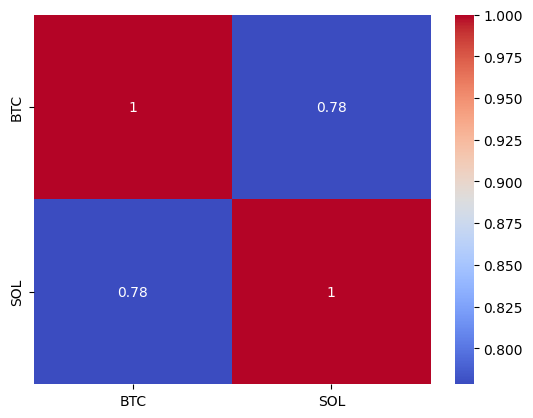

In [8]:
# ============================================================
# CELDA 8 — CORRELACIÓN
# ============================================================
returns = pd.DataFrame({
    'BTC': data['BTC-USD'].pct_change(),
    'SOL': data['SOL-USD'].pct_change(),
})
corr = returns.corr()

import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [9]:
# ============================================================
# CELDA 9 — DÍAS NEGATIVOS
# ============================================================
retornos_diarios_btc = btc['retorno'].dropna()
dias_negativos_btc = (retornos_diarios_btc < 0).sum() / len(retornos_diarios_btc) * 100
print(f'Porcentaje de días negativos para BTC: {dias_negativos_btc:.2f}%')

retornos_diarios_sol = sol['retorno'].dropna()
dias_negativos_sol = (retornos_diarios_sol < 0).sum() / len(retornos_diarios_sol) * 100
print(f'Porcentaje de días negativos para SOL: {dias_negativos_sol:.2f}%')

Porcentaje de días negativos para BTC: 49.66%
Porcentaje de días negativos para SOL: 51.36%


In [10]:
# ============================================================
# CELDA 10 — ESTRATEGIA STOP LOSS
# Perfil: BTC sale si cae 25%, SOL sale si cae 20%
# ============================================================
import plotly.express as px

UMBRAL_BTC = 0.25  # Salir si BTC cae más del 25%
UMBRAL_SOL = 0.20  # Salir si SOL cae más del 20%
capital = 100

def estrategia_stop_loss(datos, nombre, umbral):
    en_mercado = True
    capital = 100
    historico_capital = []
    precio_pico = datos.iloc[0]

    for i, precio in enumerate(datos):
        if precio > precio_pico:
            precio_pico = precio
        caida = (precio - precio_pico) / precio_pico
        if en_mercado and caida < -umbral:
            en_mercado = False
        elif not en_mercado and caida > -umbral / 2:
            en_mercado = True
        if en_mercado:
            retorno_dia = datos.pct_change().iloc[i] if i > 0 else 0
            capital = capital * (1 + retorno_dia)
        historico_capital.append(capital)

    return historico_capital, capital

hist_btc, cap_btc = estrategia_stop_loss(btc['Close']['BTC-USD'], 'BTC', umbral=UMBRAL_BTC)
hist_sol, cap_sol = estrategia_stop_loss(sol['Close']['SOL-USD'], 'SOL', umbral=UMBRAL_SOL)

print(f'BTC (umbral {UMBRAL_BTC*100:.0f}%) — Capital final: ${cap_btc:.2f}')
print(f'SOL (umbral {UMBRAL_SOL*100:.0f}%) — Capital final: ${cap_sol:.2f}')

fig = px.line(x=btc.index, y=hist_btc,
              title=f'Estrategia Stop Loss {UMBRAL_BTC*100:.0f}% — BTC',
              color_discrete_sequence=['#00d4ff'])
fig.update_layout(xaxis_title='Fecha', yaxis_title='Capital ($)', template='plotly_dark')
fig.show()

fig2 = px.line(x=sol.index, y=hist_sol,
               title=f'Estrategia Stop Loss {UMBRAL_SOL*100:.0f}% — SOL',
               color_discrete_sequence=['#7c3aed'])
fig2.update_layout(xaxis_title='Fecha', yaxis_title='Capital ($)', template='plotly_dark')
fig2.show()

BTC (umbral 25%) — Capital final: $167.61
SOL (umbral 20%) — Capital final: $153.35


In [11]:
# ============================================================
# CELDA 11 — GRÁFICA CON LÍNEAS DE REFERENCIA
# ============================================================
import plotly.express as px
import plotly.graph_objects as go

# BTC
fig = go.Figure()
fig.add_trace(go.Scatter(x=btc.index, y=hist_btc,
                         name='Capital BTC', line=dict(color='#00d4ff')))
fig.add_hline(y=100, line_dash='dash', line_color='gray', annotation_text='Capital inicial $100')
fig.add_hline(y=112.5, line_dash='dot', line_color='green', annotation_text='Recuperación +12.5% → Volver a entrar')
fig.add_hline(y=75, line_dash='dot', line_color='red', annotation_text='Caída -25% → Salir del mercado')
fig.update_layout(title='Estrategia Stop Loss 25% — BTC',
                  xaxis_title='Fecha', yaxis_title='Capital ($)', template='plotly_dark')
fig.show()

# SOL
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=sol.index, y=hist_sol,
                          name='Capital SOL', line=dict(color='#7c3aed')))
fig2.add_hline(y=100, line_dash='dash', line_color='gray', annotation_text='Capital inicial $100')
fig2.add_hline(y=110, line_dash='dot', line_color='green', annotation_text='Recuperación +10% → Volver a entrar')
fig2.add_hline(y=80, line_dash='dot', line_color='red', annotation_text='Caída -20% → Salir del mercado')
fig2.update_layout(title='Estrategia Stop Loss 20% — SOL',
                   xaxis_title='Fecha', yaxis_title='Capital ($)', template='plotly_dark')
fig2.show()

In [12]:
# ============================================================
# CELDA 12 — BACKTESTING vs BUY & HOLD
# ============================================================
import plotly.graph_objects as go

buyhold_btc = (1 + btc['retorno']).cumprod() * 100
buyhold_sol = (1 + sol['retorno']).cumprod() * 100

print('======= BTC =======')
print(f'Estrategia Stop Loss 25%:  ${cap_btc:.2f}')
print(f'Buy & Hold:                ${buyhold_btc.iloc[-1]:.2f}')

print('\n======= SOL =======')
print(f'Estrategia Stop Loss 20%:  ${cap_sol:.2f}')
print(f'Buy & Hold:                ${buyhold_sol.iloc[-1]:.2f}')

# BTC
fig = go.Figure()
fig.add_trace(go.Scatter(x=btc.index, y=hist_btc,
                         name='Estrategia Stop Loss 25%', line=dict(color='#00d4ff')))
fig.add_trace(go.Scatter(x=btc.index, y=buyhold_btc,
                         name='Buy & Hold', line=dict(color='gray', dash='dash')))
fig.add_hline(y=100, line_dash='dot', line_color='white', annotation_text='Capital inicial $100')
fig.update_layout(title='Backtesting — Estrategia vs Buy & Hold BTC',
                  xaxis_title='Fecha', yaxis_title='Capital ($)', template='plotly_dark')
fig.show()

# SOL
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=sol.index, y=hist_sol,
                          name='Estrategia Stop Loss 20%', line=dict(color='#7c3aed')))
fig2.add_trace(go.Scatter(x=sol.index, y=buyhold_sol,
                          name='Buy & Hold', line=dict(color='gray', dash='dash')))
fig2.add_hline(y=100, line_dash='dot', line_color='white', annotation_text='Capital inicial $100')
fig2.update_layout(title='Backtesting — Estrategia vs Buy & Hold SOL',
                   xaxis_title='Fecha', yaxis_title='Capital ($)', template='plotly_dark')
fig2.show()

======= BTC =======
Estrategia Stop Loss 25%:  $167.61
Buy & Hold:                $144.94

======= SOL =======
Estrategia Stop Loss 20%:  $153.35
Buy & Hold:                $65.39


In [13]:
# ============================================================
# CELDA 13 — CAÍDAS EXTREMAS Y RECUPERACIÓN
# ============================================================
import plotly.graph_objects as go
import numpy as np

UMBRAL_CAIDA = -0.05

caidas_btc = btc['retorno'][btc['retorno'] < UMBRAL_CAIDA]
caidas_sol = sol['retorno'][sol['retorno'] < UMBRAL_CAIDA]

def dias_recuperacion(precios, fecha_caida, ventana=30):
    precio_antes = precios.loc[fecha_caida]
    precios_despues = precios.loc[fecha_caida:].iloc[1:ventana]
    recuperado = precios_despues[precios_despues >= precio_antes]
    if len(recuperado) > 0:
        return (recuperado.index[0] - fecha_caida).days
    return None

resultados_btc = []
for fecha in caidas_btc.index:
    dias = dias_recuperacion(btc['Close']['BTC-USD'], fecha)
    resultados_btc.append({'fecha': fecha, 'caida': caidas_btc[fecha] * 100, 'dias_recuperacion': dias})

resultados_sol = []
for fecha in caidas_sol.index:
    dias = dias_recuperacion(sol['Close']['SOL-USD'], fecha)
    resultados_sol.append({'fecha': fecha, 'caida': caidas_sol[fecha] * 100, 'dias_recuperacion': dias})

df_btc = pd.DataFrame(resultados_btc).dropna()
df_sol = pd.DataFrame(resultados_sol).dropna()

print('======= BTC =======')
print(f'Total caídas extremas:        {len(caidas_btc)} días')
print(f'Promedio de caída:            {caidas_btc.mean()*100:.2f}%')
print(f'Peor caída:                   {caidas_btc.min()*100:.2f}%')
print(f'Promedio días recuperación:   {df_btc["dias_recuperacion"].mean():.1f} días')

print('\n======= SOL =======')
print(f'Total caídas extremas:        {len(caidas_sol)} días')
print(f'Promedio de caída:            {caidas_sol.mean()*100:.2f}%')
print(f'Peor caída:                   {caidas_sol.min()*100:.2f}%')
print(f'Promedio días recuperación:   {df_sol["dias_recuperacion"].mean():.1f} días')

# Gráfica BTC
fig = go.Figure()
fig.add_trace(go.Scatter(x=btc.index, y=btc['Close']['BTC-USD'],
                         name='Precio BTC', line=dict(color='#00d4ff')))
fig.add_trace(go.Scatter(x=caidas_btc.index,
                         y=btc['Close']['BTC-USD'].loc[caidas_btc.index],
                         mode='markers', name='Caída extrema > 5%',
                         marker=dict(color='red', size=8, symbol='triangle-down')))
fig.update_layout(title='Caídas Extremas BTC', xaxis_title='Fecha',
                  yaxis_title='Precio ($)', template='plotly_dark')
fig.show()

# Gráfica SOL
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=sol.index, y=sol['Close']['SOL-USD'],
                          name='Precio SOL', line=dict(color='#7c3aed')))
fig2.add_trace(go.Scatter(x=caidas_sol.index,
                          y=sol['Close']['SOL-USD'].loc[caidas_sol.index],
                          mode='markers', name='Caída extrema > 5%',
                          marker=dict(color='red', size=8, symbol='triangle-down')))
fig2.update_layout(title='Caídas Extremas SOL', xaxis_title='Fecha',
                   yaxis_title='Precio ($)', template='plotly_dark')
fig2.show()

# Tiempo de recuperación
fig3 = go.Figure()
fig3.add_trace(go.Bar(x=df_btc['fecha'], y=df_btc['dias_recuperacion'],
                      name='BTC', marker_color='#00d4ff', width=5 * 24 * 60 * 60 * 1000))
fig3.add_trace(go.Bar(x=df_sol['fecha'], y=df_sol['dias_recuperacion'],
                      name='SOL', marker_color='#7c3aed', width=5 * 24 * 60 * 60 * 1000))
fig3.update_layout(title='Días para Recuperarse — BTC vs SOL',
                   xaxis_title='Fecha de caída', yaxis_title='Días para recuperarse',
                   barmode='group', template='plotly_dark')
fig3.show()

======= BTC =======
Total caídas extremas:        25 días
Promedio de caída:            -6.43%
Peor caída:                   -14.13%
Promedio días recuperación:   3.7 días

======= SOL =======
Total caídas extremas:        79 días
Promedio de caída:            -7.47%
Peor caída:                   -20.43%
Promedio días recuperación:   3.6 días


In [14]:
%%writefile /content/app.py
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date

st.set_page_config(
    page_title="Cripto Uno A — Fondo de Inversión",
    page_icon="₿",
    layout="wide"
)

st.markdown("""
<style>
    /* Move sidebar to the right */
    [data-testid="stSidebar"] {
        order: 1;
    }
    [data-testid="stSidebarContent"] {
        text-align: right;
    }
    [data-testid="stSidebar"] .stSelectbox,
    [data-testid="stSidebar"] .stSlider,
    [data-testid="stSidebar"] .stDateInput,
    [data-testid="stSidebar"] .stRadio,
    [data-testid="stSidebar"] .stCheckbox,
    [data-testid="stSidebar"] label {
        direction: rtl;
        text-align: right;
    }
    [data-testid="stSidebar"] select,
    [data-testid="stSidebar"] input {
        text-align: right;
    }
    /* Push main content to left */
    .main .block-container {
        margin-left: 0 !important;
        margin-right: auto !important;
    }
    section[data-testid="stSidebar"] {
        left: unset !important;
        right: 0 !important;
        position: fixed !important;
    }
</style>
""", unsafe_allow_html=True)

st.markdown("""
<style>
    .main { background-color: #f0f0f0; }
    .metric-card {
        background: linear-gradient(135deg, #ffffff, #e8e8e8);
        border-radius: 8px;
        padding: 20px;
        text-align: center;
        border: 1px solid #cccccc;
        margin-bottom: 10px;
    }
    .metric-value { font-size: 2rem; font-weight: bold; color: #000000; }
    .metric-label { font-size: 0.9rem; color: #444444; margin-top: 4px; }
    .section-title {
        font-size: 1.4rem;
        font-weight: bold;
        color: #000000;
        border-left: 4px solid #000000;
        padding-left: 12px;
        margin: 30px 0 15px 0;
    }
    .explanation-box {
        background: #ffffff;
        border-radius: 8px;
        padding: 16px 20px;
        border-left: 3px solid #7c3aed;
        color: #444444;
        font-size: 0.95rem;
        margin-bottom: 20px;
    }
    .resumen-card {
        background: linear-gradient(135deg, #ffffff, #e8e8e8);
        border-radius: 10px;
        padding: 20px;
        text-align: center;
        border: 1px solid #dddddd;
        margin-bottom: 12px;
        transition: border-color 0.2s;
    }
    .resumen-card:hover { border-color: #000000; }
    .resumen-value { font-size: 1.8rem; font-weight: bold; color: #000000; }
    .resumen-label { font-size: 0.8rem; color: #555555; text-transform: uppercase; letter-spacing: 0.05em; margin-top: 4px; }
    .resumen-sub { font-size: 0.85rem; margin-top: 6px; }
</style>
""", unsafe_allow_html=True)

# ---- SIDEBAR ----
with st.sidebar:
    st.markdown("## ⚙️ Controles")
    st.markdown("---")

    st.markdown("### 🪙 Selecciona la criptomoneda")
    CRIPTOS_DISPONIBLES = {
        "Bitcoin (BTC)":        {"ticker": "BTC-USD",  "color": "#39d353", "umbral": 0.25},
        "Solana (SOL)":         {"ticker": "SOL-USD",  "color": "#7c3aed", "umbral": 0.20},
        "Ethereum (ETH)":       {"ticker": "ETH-USD",  "color": "#4a9eff", "umbral": 0.20},
        "BNB (BNB)":            {"ticker": "BNB-USD",  "color": "#f0b429", "umbral": 0.22},
        "XRP (XRP)":            {"ticker": "XRP-USD",  "color": "#346aa9", "umbral": 0.22},
        "Cardano (ADA)":        {"ticker": "ADA-USD",  "color": "#0033ad", "umbral": 0.22},
        "Avalanche (AVAX)":     {"ticker": "AVAX-USD", "color": "#e84142", "umbral": 0.22},
        "Dogecoin (DOGE)":      {"ticker": "DOGE-USD", "color": "#c2a633", "umbral": 0.22},
        "Polkadot (DOT)":       {"ticker": "DOT-USD",  "color": "#e6007a", "umbral": 0.22},
        "Chainlink (LINK)":     {"ticker": "LINK-USD", "color": "#2a5ada", "umbral": 0.22},
    }

    cripto_nombre = st.selectbox(
        "Criptomoneda a analizar:",
        options=list(CRIPTOS_DISPONIBLES.keys()),
        index=0
    )

    cripto_info  = CRIPTOS_DISPONIBLES[cripto_nombre]
    TICKER       = cripto_info["ticker"]
    COLOR        = cripto_info["color"]
    UMBRAL       = cripto_info["umbral"]
    SIMBOLO      = TICKER.replace("-USD", "")

    st.markdown("---")
    st.markdown("### 📅 Período de análisis")
    fecha_inicio = st.date_input("Fecha de inicio", value=date(2024, 1, 1),
        min_value=date(2020, 1, 1), max_value=date.today())
    fecha_fin = st.date_input("Fecha de fin", value=date.today(),
        min_value=date(2020, 1, 2), max_value=date.today())
    if fecha_inicio >= fecha_fin:
        st.error("⚠️ La fecha inicio debe ser menor que la fecha fin")
        st.stop()

    st.markdown("---")
    st.markdown("### 📊 Frecuencia")
    frecuencia = st.selectbox("Frecuencia:",
        options=["Diaria", "Semanal", "Mensual"], index=0)
    freq_map = {"Diaria": "1d", "Semanal": "1wk", "Mensual": "1mo"}
    freq_yf = freq_map[frecuencia]

    st.markdown("---")
    st.markdown("### 💰 Inversión hipotética")
    monto = st.number_input("¿Cuánto habría invertido? ($)",
        min_value=100, max_value=1000000, value=1000, step=100)

    st.markdown("---")
    st.markdown(f"### 📌 Parámetro Stop Loss")
    st.markdown(f"**Umbral automático: {UMBRAL*100:.0f}%**")
    st.caption("Ajustado según la volatilidad histórica de cada cripto.")

# ---- CARGAR DATOS ----
@st.cache_data
def cargar_datos(ticker, inicio, fin, frecuencia):
    df = yf.download(ticker, start=inicio, end=fin, interval=frecuencia)
    df['retorno'] = df['Close'][ticker].pct_change()
    return df

with st.spinner(f"Cargando datos de {cripto_nombre}..."):
    df = cargar_datos(
        TICKER,
        fecha_inicio.strftime("%Y-%m-%d"),
        fecha_fin.strftime("%Y-%m-%d"),
        freq_yf
    )

precios = df['Close'][TICKER]

# ---- FUNCIONES ----
def max_drawdown(serie):
    pico = serie.cummax()
    return (serie - pico) / pico * 100

def estrategia_stop_loss(datos, umbral, capital_inicial=100):
    en_mercado  = True
    capital     = capital_inicial
    historico   = []
    precio_pico = datos.iloc[0]
    for i, precio in enumerate(datos):
        if precio > precio_pico:
            precio_pico = precio
        caida = (precio - precio_pico) / precio_pico
        if en_mercado and caida < -umbral:
            en_mercado = False
        elif not en_mercado and caida > -umbral / 2:
            en_mercado = True
        if en_mercado:
            r = datos.pct_change().iloc[i] if i > 0 else 0
            capital = capital * (1 + r)
        historico.append(capital)
    return historico, capital

# ---- CÁLCULOS ----
hist_sl, cap_sl   = estrategia_stop_loss(precios, UMBRAL, capital_inicial=monto)
buyhold           = (1 + df['retorno']).cumprod() * monto
drawdown          = max_drawdown(precios)
vol_anual         = df['retorno'].dropna().std() * np.sqrt(252) * 100
dias_neg          = (df['retorno'].dropna() < 0).sum() / len(df['retorno'].dropna()) * 100
precio_hoy        = precios.iloc[-1]
rend_total        = (precios.iloc[-1] / precios.iloc[0] - 1) * 100
bh_final          = buyhold.iloc[-1]
ventaja           = cap_sl - bh_final
diferencia        = cap_sl - bh_final

# ============================================================
# HEADER
# ============================================================
st.markdown(f"""
<div style="text-align:center; padding: 20px 0 10px 0;">
    <h1 style="color:{COLOR}; font-size:2.5rem; margin-bottom:0; letter-spacing:0.08em">
        ₿ CRIPTO UNO A
    </h1>
    <p style="color:#444444; font-size:1.1rem; margin-top:6px">
        Fondo de Inversión · <b style="color:{COLOR}">{cripto_nombre}</b> · Perfil Moderado
    </p>
</div>
""", unsafe_allow_html=True)

st.markdown(f"""
<div class="explanation-box">
📅 Analizando <b>{cripto_nombre}</b> desde <b>{fecha_inicio.strftime('%d/%m/%Y')}</b>
hasta <b>{fecha_fin.strftime('%d/%m/%Y')}</b>
&nbsp;·&nbsp; <b>{(fecha_fin - fecha_inicio).days} días</b>
&nbsp;·&nbsp; Frecuencia: <b>{frecuencia}</b>
&nbsp;·&nbsp; Inversión hipotética: <b>${monto:,}</b>
</div>
""", unsafe_allow_html=True)

# ============================================================
# RESUMEN EJECUTIVO
# ============================================================
st.markdown('<div class="section-title">📊 Resumen Ejecutivo</div>', unsafe_allow_html=True)

col1, col2, col3, col4 = st.columns(4)
with col1:
    color_rend = "#39d353" if rend_total > 0 else "#f85149"
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value" style="color:{COLOR}">${precio_hoy:,.2f}</div>
        <div class="resumen-label">Precio {SIMBOLO} hoy</div>
        <div class="resumen-sub" style="color:{color_rend}">
            {"▲" if rend_total > 0 else "▼"} {abs(rend_total):.1f}% en el período
        </div>
    </div>""", unsafe_allow_html=True)
with col2:
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value">{vol_anual:.1f}%</div>
        <div class="resumen-label">Volatilidad Anual</div>
        <div class="resumen-sub" style="color:#444444">Ref. acciones: ~27%</div>
    </div>""", unsafe_allow_html=True)
with col3:
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value" style="color:#f85149">{drawdown.min():.1f}%</div>
        <div class="resumen-label">Peor caída desde pico</div>
        <div class="resumen-sub" style="color:#444444">Máximo Drawdown</div>
    </div>""", unsafe_allow_html=True)
with col4:
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value">{dias_neg:.1f}%</div>
        <div class="resumen-label">Días negativos</div>
        <div class="resumen-sub" style="color:#444444">Frecuencia: {frecuencia.lower()}</div>
    </div>""", unsafe_allow_html=True)

col1, col2, col3, col4 = st.columns(4)
with col1:
    color_sl = "#39d353" if cap_sl > monto else "#f85149"
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value" style="color:{color_sl}">${cap_sl:,.0f}</div>
        <div class="resumen-label">${monto:,} con Stop Loss {UMBRAL*100:.0f}%</div>
        <div class="resumen-sub" style="color:#444444">Capital final</div>
    </div>""", unsafe_allow_html=True)
with col2:
    color_bh = "#39d353" if bh_final > monto else "#f85149"
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value" style="color:{color_bh}">${bh_final:,.0f}</div>
        <div class="resumen-label">${monto:,} Buy & Hold</div>
        <div class="resumen-sub" style="color:#444444">Sin estrategia</div>
    </div>""", unsafe_allow_html=True)
with col3:
    color_vent = "#39d353" if ventaja > 0 else "#f85149"
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value" style="color:{color_vent}">
            {"+" if ventaja > 0 else ""}{ventaja:,.0f}$
        </div>
        <div class="resumen-label">Ventaja estrategia vs B&H</div>
        <div class="resumen-sub" style="color:#444444">Stop Loss vs Buy & Hold</div>
    </div>""", unsafe_allow_html=True)
with col4:
    st.markdown(f"""
    <div class="resumen-card">
        <div class="resumen-value">{UMBRAL*100:.0f}%</div>
        <div class="resumen-label">Umbral Stop Loss</div>
        <div class="resumen-sub" style="color:#444444">Re-entrada al {UMBRAL*50:.0f}%</div>
    </div>""", unsafe_allow_html=True)

st.markdown("---")

# ============================================================
# 1. PRECIOS
# ============================================================
st.markdown(f'<div class="section-title">📈 1. Evolución del Precio — {cripto_nombre}</div>', unsafe_allow_html=True)
st.markdown(f'<div class="explanation-box">📌 Precio histórico de <b>{cripto_nombre}</b> en el período seleccionado.</div>', unsafe_allow_html=True)
fig = px.line(x=df.index, y=precios, title=f"{cripto_nombre} — Precio en USD",
              color_discrete_sequence=[COLOR])
fig.update_layout(xaxis_title="Fecha", yaxis_title="Precio (USD)", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 2. RETORNOS
# ============================================================
st.markdown(f'<div class="section-title">📊 2. Movimientos {frecuencia}</div>', unsafe_allow_html=True)
st.markdown(f'<div class="explanation-box">📌 Cuánto sube o baja el precio cada período. Frecuencia seleccionada: <b>{frecuencia}</b>.</div>', unsafe_allow_html=True)
fig = px.line(x=df.index, y=df['retorno'], title=f"Retornos {frecuencia} — {SIMBOLO}",
              color_discrete_sequence=[COLOR])
fig.update_layout(xaxis_title="Fecha", yaxis_title=f"Retorno {frecuencia}", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 3. RENDIMIENTO ACUMULADO
# ============================================================
st.markdown('<div class="section-title">💰 3. ¿Cuánto habría ganado?</div>', unsafe_allow_html=True)
st.markdown(f'<div class="explanation-box">📌 Si hubiera invertido <b>${monto:,}</b> el <b>{fecha_inicio.strftime("%d/%m/%Y")}</b>, así habría evolucionado su capital.</div>', unsafe_allow_html=True)
rend_acum = (1 + df['retorno']).cumprod() * monto
fig = px.line(x=df.index, y=rend_acum, title=f"Rendimiento Acumulado — {cripto_nombre} (Base ${monto:,})",
              color_discrete_sequence=[COLOR])
fig.add_hline(y=monto, line_dash="dot", line_color="gray", annotation_text=f"Inversión inicial ${monto:,}")
fig.update_layout(xaxis_title="Fecha", yaxis_title=f"Valor (USD)", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 4. VOLATILIDAD
# ============================================================
st.markdown('<div class="section-title">⚡ 4. Riesgo — Volatilidad</div>', unsafe_allow_html=True)
st.markdown('<div class="explanation-box">📌 <b>¿Qué es la volatilidad?</b> Qué tan brusco es el precio. Alta volatilidad = puede subir o bajar mucho en poco tiempo. Acciones como Apple tienen ~27%.</div>', unsafe_allow_html=True)
col1, col2 = st.columns(2)
with col1:
    st.markdown(f'<div class="metric-card"><div class="metric-value" style="color:{COLOR}">{vol_anual:.1f}%</div><div class="metric-label">Volatilidad Anual {SIMBOLO}</div></div>', unsafe_allow_html=True)
with col2:
    st.markdown('<div class="metric-card"><div class="metric-value">~27%</div><div class="metric-label">Volatilidad Típica Acciones</div></div>', unsafe_allow_html=True)
fig = px.bar(x=[SIMBOLO, "Acciones típicas"], y=[vol_anual, 27],
             title=f"Volatilidad Anualizada — {SIMBOLO} vs Acciones",
             color=[SIMBOLO, "Acciones típicas"],
             color_discrete_map={SIMBOLO: COLOR, "Acciones típicas": "#39d353"})
fig.update_layout(template="plotly_white", showlegend=False, xaxis_title="Activo", yaxis_title="Volatilidad (%)")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 5. DRAWDOWN
# ============================================================
st.markdown('<div class="section-title">📉 5. Peor Caída Histórica</div>', unsafe_allow_html=True)
st.markdown('<div class="explanation-box">📌 <b>¿Qué es el Drawdown?</b> La caída desde el punto más alto hasta el más bajo. Es la métrica más honesta del riesgo real.</div>', unsafe_allow_html=True)
st.markdown(f'<div class="metric-card"><div class="metric-value" style="color:#f85149">{drawdown.min():.1f}%</div><div class="metric-label">Peor caída {SIMBOLO} desde su pico</div></div>', unsafe_allow_html=True)
fig = px.line(x=df.index, y=drawdown, title=f"Drawdown — {SIMBOLO}",
              color_discrete_sequence=['#f85149'])
fig.update_layout(xaxis_title="Fecha", yaxis_title="Caída (%)", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 6. DÍAS NEGATIVOS
# ============================================================
st.markdown(f'<div class="section-title">🔴 6. Frecuencia de Pérdidas ({frecuencia})</div>', unsafe_allow_html=True)
st.markdown(f'<div class="explanation-box">📌 De cada 100 períodos ({frecuencia.lower()}), cuántos terminaron con el precio más bajo.</div>', unsafe_allow_html=True)
st.markdown(f'<div class="metric-card"><div class="metric-value">{dias_neg:.1f}%</div><div class="metric-label">Períodos negativos {SIMBOLO}</div></div>', unsafe_allow_html=True)
fig = px.histogram(df, x='retorno', nbins=50, title=f'Distribución de Retornos — {SIMBOLO}',
                   color_discrete_sequence=[COLOR])
fig.update_layout(xaxis_title="Retorno", yaxis_title="Cantidad", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 7. ESTRATEGIA STOP LOSS
# ============================================================
st.markdown('<div class="section-title">🛡️ 7. Nuestra Estrategia de Protección</div>', unsafe_allow_html=True)
st.markdown(f"""
<div class="explanation-box">
📌 <b>¿Cómo protegemos su dinero?</b><br><br>
🔴 <b>Si {SIMBOLO} cae más del {UMBRAL*100:.0f}%</b> desde su punto más alto → Salimos y protegemos el capital<br>
🟢 Cuando el precio se recupera <b>{UMBRAL*50:.0f}%</b> → Volvemos a entrar para capturar las ganancias<br><br>
Esto elimina las decisiones emocionales — la regla manda, no el pánico.
</div>
""", unsafe_allow_html=True)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=hist_sl, name=f'Stop Loss {UMBRAL*100:.0f}%', line=dict(color=COLOR)))
fig.add_hline(y=monto, line_dash="dash", line_color="gray", annotation_text=f"Capital inicial ${monto:,}")
fig.add_hline(y=monto * (1 + UMBRAL/2), line_dash="dot", line_color="green", annotation_text=f"Re-entrada +{UMBRAL*50:.0f}%")
fig.add_hline(y=monto * (1 - UMBRAL), line_dash="dot", line_color="red", annotation_text=f"Salir -{UMBRAL*100:.0f}%")
fig.update_layout(title=f"Estrategia Stop Loss {UMBRAL*100:.0f}% — {SIMBOLO}",
                  xaxis_title="Fecha", yaxis_title="Capital ($)", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 8. BACKTESTING
# ============================================================
st.markdown('<div class="section-title">⚔️ 8. Estrategia vs No hacer Nada</div>', unsafe_allow_html=True)
st.markdown('<div class="explanation-box">📌 <b>¿Qué es el Backtesting?</b> Aplicamos nuestra estrategia hacia atrás para ver cómo hubiera funcionado. La línea de color es nuestra estrategia. La gris punteada es comprar y no hacer nada.</div>', unsafe_allow_html=True)
color_dif = "#39d353" if diferencia > 0 else "#f85149"
st.markdown(f'<div class="metric-card"><div class="metric-value" style="color:{color_dif}">{"+" if diferencia > 0 else ""}{diferencia:.2f}$</div><div class="metric-label">Ventaja estrategia vs Buy & Hold {SIMBOLO}</div></div>', unsafe_allow_html=True)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=hist_sl, name=f'Stop Loss {UMBRAL*100:.0f}%', line=dict(color=COLOR)))
fig.add_trace(go.Scatter(x=df.index, y=buyhold, name='Buy & Hold', line=dict(color='gray', dash='dash')))
fig.add_hline(y=monto, line_dash="dot", line_color="white", annotation_text=f"Capital inicial ${monto:,}")
fig.update_layout(title=f"Backtesting — Estrategia vs Buy & Hold {SIMBOLO}",
                  xaxis_title="Fecha", yaxis_title="Capital ($)", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# 9. CAÍDAS EXTREMAS
# ============================================================
st.markdown('<div class="section-title">🌊 9. Caídas Extremas y Recuperación</div>', unsafe_allow_html=True)
st.markdown('<div class="explanation-box">📌 Días donde el precio cayó más del 5% en un solo día. Los triángulos rojos marcan esos días.</div>', unsafe_allow_html=True)

UMBRAL_CAIDA = -0.05
caidas = df['retorno'][df['retorno'] < UMBRAL_CAIDA]

def dias_recuperacion(precios, fecha_caida, ventana=30):
    precio_antes = precios.loc[fecha_caida]
    precios_despues = precios.loc[fecha_caida:].iloc[1:ventana]
    recuperado = precios_despues[precios_despues >= precio_antes]
    if len(recuperado) > 0:
        return (recuperado.index[0] - fecha_caida).days
    return None

resultados = []
for fecha in caidas.index:
    dias = dias_recuperacion(precios, fecha)
    resultados.append({'fecha': fecha, 'caida': caidas[fecha] * 100, 'dias_recuperacion': dias})

df_caidas = pd.DataFrame(resultados).dropna()

col1, col2, col3 = st.columns(3)
with col1:
    st.markdown(f'<div class="metric-card"><div class="metric-value">{len(caidas)}</div><div class="metric-label">Caídas extremas {SIMBOLO}</div></div>', unsafe_allow_html=True)
with col2:
    st.markdown(f'<div class="metric-card"><div class="metric-value">{caidas.mean()*100:.2f}%</div><div class="metric-label">Promedio de caída</div></div>', unsafe_allow_html=True)
with col3:
    prom_rec = df_caidas["dias_recuperacion"].mean() if len(df_caidas) > 0 else 0
    st.markdown(f'<div class="metric-card"><div class="metric-value">{prom_rec:.0f} días</div><div class="metric-label">Recuperación promedio</div></div>', unsafe_allow_html=True)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=precios, name=f'Precio {SIMBOLO}', line=dict(color=COLOR)))
fig.add_trace(go.Scatter(x=caidas.index, y=precios.loc[caidas.index],
                         mode='markers', name='Caída > 5%',
                         marker=dict(color='red', size=8, symbol='triangle-down')))
fig.update_layout(title=f"Caídas Extremas — {SIMBOLO}", xaxis_title="Fecha",
                  yaxis_title="Precio ($)", template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

if len(df_caidas) > 0:
    fig2 = go.Figure()
    fig2.add_trace(go.Bar(x=df_caidas['fecha'], y=df_caidas['dias_recuperacion'],
                          name=SIMBOLO, marker_color=COLOR, width=5*24*60*60*1000))
    fig2.update_layout(title=f"Días para Recuperarse — {SIMBOLO}",
                       xaxis_title="Fecha de caída", yaxis_title="Días para recuperarse",
                       template="plotly_white")
    st.plotly_chart(fig2, use_container_width=True)

# CIERRE
st.markdown("---")
st.markdown(f"""
<div style="text-align:center; padding: 40px;">
    <h2 style="color:{COLOR}">¿Por qué invertir en Cripto Uno A?</h2>
    <p style="color:#444444; font-size:1.1rem; max-width:700px; margin:auto">
    Analizamos <b style="color:{COLOR}">{cripto_nombre}</b> con datos reales y estrategias basadas en reglas.
    Sin emociones, sin improvisación. Así se invierte de forma inteligente.
    </p>
</div>
""", unsafe_allow_html=True)

st.markdown("---")
st.markdown("""
<div style="background:#ffffff; border-radius:8px; padding:30px; border:1px solid #21262d; margin-top:20px;">
    <h4 style="color:#000000; margin-bottom:16px">⚠️ Aviso Legal</h4>
    <p style="color:#555555; font-size:0.9rem; line-height:1.8">
    Datos obtenidos de <b>Yahoo Finance</b> vía yfinance. Procesado con Python, pandas, numpy y plotly.<br>
    Código desarrollado con apoyo de <b>Claude (Anthropic)</b>.<br><br>
    <b style="color:#f85149">⚠️ Este análisis NO constituye asesoría financiera.</b>
    Los rendimientos pasados no garantizan resultados futuros.
    Invertir en criptomonedas conlleva riesgos significativos.
    </p>
</div>
""", unsafe_allow_html=True)

st.markdown(f'<div style="text-align:center; padding:20px; color:#888888; font-size:0.8rem;">Cripto Uno A · {cripto_nombre} · Python · yfinance · plotly · streamlit · Claude AI · © 2026</div>', unsafe_allow_html=True)


Writing /content/app.py


In [15]:
# ============================================================
# CELDA 15 — INSTALAR STREAMLIT Y PYNGROK
# ⏳ Espera que termine antes de continuar
# ============================================================
!pip install streamlit pyngrok yfinance plotly pandas numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.4 MB/s eta 0:00:00


In [16]:
# ============================================================
# CELDA 16 — VERIFICAR QUE app.py EXISTE
# ✅ Debe imprimir True
# ============================================================
import os
exists = os.path.exists('/content/app.py')
print('✅ app.py encontrado!' if exists else '❌ app.py NO encontrado — vuelve a ejecutar la Celda 14')

✅ app.py encontrado!


In [17]:
# ============================================================
# CELDA 17 — LANZAR LA APP CON NGROK
# ✅ Al final te dará un enlace público para ver la app
# ============================================================
import subprocess
import time
from pyngrok import ngrok

# Matar procesos anteriores
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

# Lanzar Streamlit
proceso = subprocess.Popen(
    ['/usr/local/bin/streamlit', 'run', '/content/app.py',
     '--server.port=8501',
     '--server.headless=true',
     '--server.enableCORS=false',
     '--server.enableXsrfProtection=false'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

if proceso.poll() is None:
    print('✅ Streamlit corriendo!')
else:
    out, err = proceso.communicate()
    print(f'❌ Error: {err.decode()}')

# Conectar ngrok
ngrok.kill()
time.sleep(1)
ngrok.set_auth_token('3EbTqHrowFYdDAfVfvGXmAgfpZA_5mmRMSF4Prt9owqJJUoFE')
public_url = ngrok.connect(8501)
print(f'✅ Tu app está en: {public_url}')
print('👆 Haz clic en ese enlace para abrir la app')

✅ Streamlit corriendo!
✅ Tu app está en: NgrokTunnel: "https://sharper-mousy-rephrase.ngrok-free.dev" -> "http://localhost:8501"
👆 Haz clic en ese enlace para abrir la app
